# AULA 17 - Noções do pacote PANDAS -  parte C
## Algoritmos e Estrutura de Dados I - Prof. Piva
-----------

### Dividindo Strings em DataFrames com Pandas (split)
Com Pandas, podemos fazer várias tarefas de divisão (split) de strings, dividindo colunas ou extraindo elementos.

In [1]:
# Importando o Pandas
import pandas as pd
# Verificando a Versão do Pandas
pd.__version__

'1.5.3'

In [2]:
# Importando um dataset que está em um arquivo CSV
df = pd.read_csv("dataset.csv")

In [3]:
df.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,NaN
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0


In [4]:
df['ID_Pedido'].head()

0    CA-2016-152156
1    CA-2016-152156
2    CA-2016-138688
3    US-2015-108966
4    US-2015-108966
Name: ID_Pedido, dtype: object

Ao analisarmos o ID_Pedido, verificamos que o mesmo é composto por 3 informações: O pais (com duas letras), o ano (4 digitos) e o número do pedido com 6 digitos.
Podemos dividir esses dados utilizando split. O resultado será uma lista com os elementos divididos.

In [5]:
df['ID_Pedido'].str.split('-')

0       [CA, 2016, 152156]
1       [CA, 2016, 152156]
2       [CA, 2016, 138688]
3       [US, 2015, 108966]
4       [US, 2015, 108966]
               ...        
9989    [CA, 2014, 110422]
9990    [CA, 2017, 121258]
9991    [CA, 2017, 121258]
9992    [CA, 2017, 121258]
9993    [CA, 2017, 119914]
Name: ID_Pedido, Length: 9994, dtype: object

Note que o resultado apresenta uma lista... e cada elemento pode ser acessado pelo seu índice: 0, 1 ou 2.
Se quisermos extrair apenas o ano, utilizamos o índice 1.

In [6]:
df['ID_Pedido'].str.split('-').str[1].head()

0    2016
1    2016
2    2016
3    2015
4    2015
Name: ID_Pedido, dtype: object

Vamos agora pegar esse resultado e gravar em uma nova coluna do DataFrame... chamada "Ano".

In [7]:
df['Ano'] = df['ID_Pedido'].str.split('-').str[1]

In [8]:
#Vamos conferir se a coluna foi criada...
df.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,NaN,2016
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN,2016
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,2016
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,2015
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0,2015


### Strip de Strings em DataFrames em Pandas
Remove caracteres da String

In [9]:
df['Data_Pedido'].head()

0    2016-11-08
1    2016-11-08
2    2016-06-12
3    2015-10-11
4    2015-10-11
Name: Data_Pedido, dtype: object

Vamos supor que precisamos simplificar a data, e deixar o ano apenas com dois digitos... removendo os dois primeiros caracteres '20'.

In [10]:
df['Data_Pedido'].str.lstrip('20')

0       16-11-08
1       16-11-08
2       16-06-12
3       15-10-11
4       15-10-11
          ...   
9989    14-01-21
9990    17-02-26
9991    17-02-26
9992    17-02-26
9993    17-05-04
Name: Data_Pedido, Length: 9994, dtype: object

Como dito anteriormente... os comandos do Pandas, não alteram os valores originais do dataframe.
Se quiser alterar, temos que utilizar o parâmetro inplace = True.

### Substituição de Strings em DataFrames Pandas (replace)
Podemos fazer a substituição de caracteres utilizando o método replace()

In [11]:
df.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,NaN,2016
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN,2016
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,2016
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,2015
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0,2015


In [12]:
df['ID_Cliente'] = df['ID_Cliente'].str.replace('CG', 'AX')

In [13]:
df.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano
0,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,NaN,2016
1,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN,2016
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,2016
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,2015
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0,2015


### Combinação de Strings em DataFrames Pandas
A função cat() pode ser utilizado para concatenar strings em um dataframe.
Vamos fazer a junção (concatenação) das colunas "ID_Pedido" e "Segmento"

In [14]:
df['Pedido_Segmento'] = df['ID_Pedido'].str.cat(df['Segmento'], sep = '-')

In [15]:
df.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano,Pedido_Segmento
0,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,NaN,2016,CA-2016-152156-Consumer
1,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN,2016,CA-2016-152156-Consumer
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,2016,CA-2016-138688-Corporate
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,2015,US-2015-108966-Consumer
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0,2015,US-2015-108966-Consumer


### Construção de Gráficos a partir de DataFrames Pandas
Além de todos os processos de manipulação de dados, o Pandas também possui algumas funções para exibição de gráficos a partir de dataframes. Vamos ver alguns exemplos...

In [16]:
# Vamos instalar a versão do Scikit-Learn para termos acesso ao dataset Iris
!pip install -q scikit-learn==1.2.1
import sklearn
sklearn.__version__

'1.2.1'

In [17]:
#Vmos importar o dataset Iris
from sklearn.datasets import load_iris
data = load_iris()

In [18]:
df_iris = pd.DataFrame(data['data'], columns = data['feature_names'])
df_iris['species'] = data['target']
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


<AxesSubplot:>

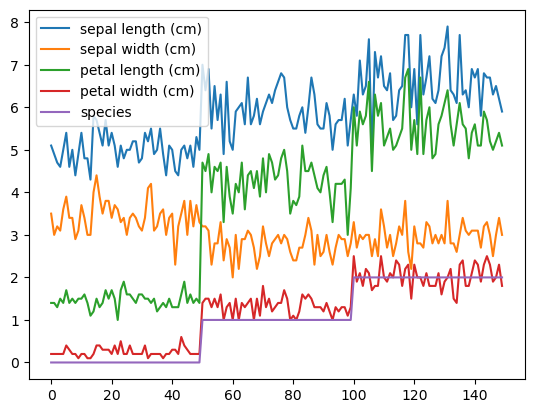

In [19]:
df_iris.plot()

<AxesSubplot:xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

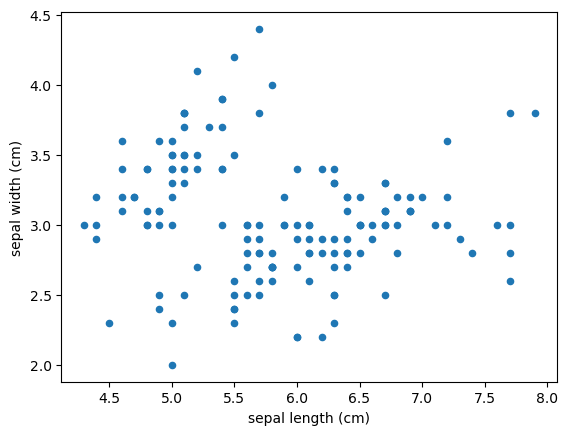

In [20]:
df_iris.plot.scatter(x = 'sepal length (cm)', y = 'sepal width (cm)')

<AxesSubplot:>

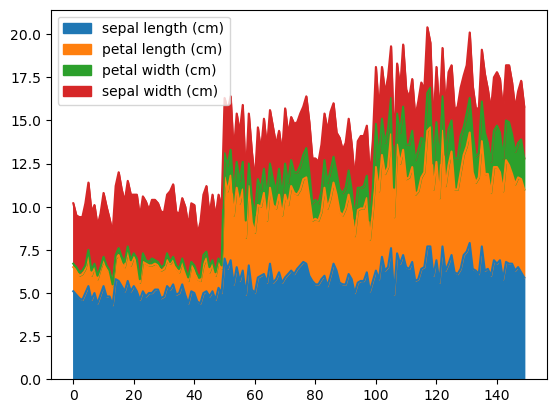

In [22]:
#Gráficos mais complexos, com área...
columns = ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)', 'sepal width (cm)']
df_iris[columns].plot.area()

<AxesSubplot:xlabel='species'>

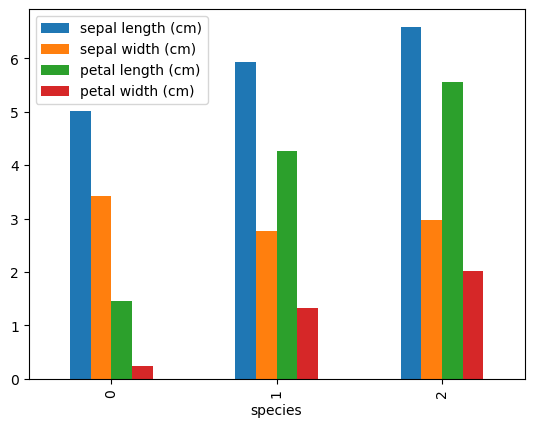

In [23]:
# Calculando a média das colunas agrupadas pela coluna species e criando um gráfico de barras com o resultado
df_iris.groupby('species').mean().plot.bar()

<AxesSubplot:ylabel='sepal length (cm)'>

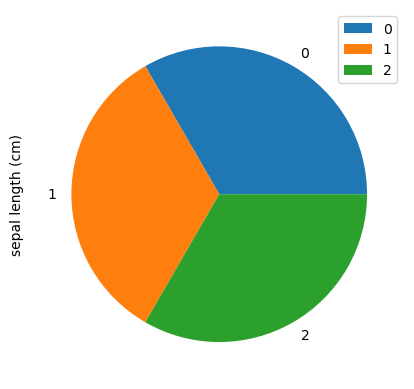

In [25]:
#Contagem das classes da coluna species e plotamos um gráfico de pizza
df_iris.groupby('species').count().plot.pie(y = 'sepal length (cm)')

## Fim